In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Install PyTorch (adjust CUDA version if needed)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Install Ultralytics (YOLO library)
!pip install ultralytics

Looking in indexes: https://download.pytorch.org/whl/cu118


In [12]:
# Create a folder to extract the dataset
!mkdir -p /content/dataset

# Replace 'your_dataset.zip' with the name of your uploaded ZIP file
!unzip /content/your_dataset.zip -d /content/dataset

Archive:  /content/your_dataset.zip
  inflating: /content/dataset/data.yaml  
  inflating: /content/dataset/__MACOSX/._data.yaml  
   creating: /content/dataset/test/
  inflating: /content/dataset/__MACOSX/._test  
   creating: /content/dataset/test/images/
  inflating: /content/dataset/__MACOSX/test/._images  
   creating: /content/dataset/test/labels/
  inflating: /content/dataset/__MACOSX/test/._labels  
  inflating: /content/dataset/test/images/5a35ba2ec3e0d0b2b12b1758a8ac29aa_jpg.rf.a907af85301c729635d6ab1c31eb31b2.jpg  
  inflating: /content/dataset/__MACOSX/test/images/._5a35ba2ec3e0d0b2b12b1758a8ac29aa_jpg.rf.a907af85301c729635d6ab1c31eb31b2.jpg  
  inflating: /content/dataset/test/images/4e3117459d759798537eb52cf5bf534d_jpg.rf.5b99421bf416463a8c75cfd07f8a68d1.jpg  
  inflating: /content/dataset/__MACOSX/test/images/._4e3117459d759798537eb52cf5bf534d_jpg.rf.5b99421bf416463a8c75cfd07f8a68d1.jpg  
  inflating: /content/dataset/test/images/f1a24b6bb778ee11ba33687415aa84f2_jpg.rf.6

In [13]:
# Check dataset structure
!ls /content/dataset

data.yaml  __MACOSX  test  train  valid


In [14]:
# Display the contents of data.yaml
!cat /content/dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']

roboflow:
  workspace: joseph-nelson
  project: chess-pieces-new
  version: 23
  license: Public Domain
  url: https://universe.roboflow.com/joseph-nelson/chess-pieces-new/dataset/23

In [15]:
# Fix paths in data.yaml to match Colab's structure
with open('/content/dataset/data.yaml', 'r') as file:
    data = file.read()

data = data.replace('../train/images', '/content/dataset/train/images')
data = data.replace('../valid/images', '/content/dataset/valid/images')
data = data.replace('../test/images', '/content/dataset/test/images')

with open('/content/dataset/data.yaml', 'w') as file:
    file.write(data)

# Verify the updated data.yaml file
!cat /content/dataset/data.yaml

train: /content/dataset/train/images
val: /content/dataset/valid/images
test: /content/dataset/test/images

nc: 13
names: ['bishop', 'black-bishop', 'black-king', 'black-knight', 'black-pawn', 'black-queen', 'black-rook', 'white-bishop', 'white-king', 'white-knight', 'white-pawn', 'white-queen', 'white-rook']

roboflow:
  workspace: joseph-nelson
  project: chess-pieces-new
  version: 23
  license: Public Domain
  url: https://universe.roboflow.com/joseph-nelson/chess-pieces-new/dataset/23

In [16]:
from ultralytics import YOLO

# Load the YOLOv8 model (pretrained weights)
model = YOLO('yolov8n.pt')  # 'yolov8n.pt' refers to the YOLOv8 Nano version

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 323MB/s]


In [17]:
# Train the YOLOv8 model on your dataset
model.train(
    data='/content/dataset/data.yaml',  # Path to the corrected data.yaml
    epochs=50,                          # Number of training epochs
    imgsz=640,                          # Image size
    batch=16,                           # Batch size
    device=0                            # Use GPU (or 'cpu' if GPU unavailable)
)

Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/dataset/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=Tr

100%|██████████| 755k/755k [00:00<00:00, 120MB/s]


Overriding model.yaml nc=80 with nc=13

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytic

100%|██████████| 5.35M/5.35M [00:00<00:00, 249MB/s]


AMP: checks passed ✅


...

                   all         58        386      0.982      0.982      0.983      0.806



50 epochs completed in 0.098 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.83it/s]


                   all         58        386      0.982      0.983      0.983      0.807
          black-bishop         13         22      0.942      0.955      0.963      0.715
            black-king         29         29          1      0.958      0.995      0.839
          black-knight         26         30      0.992          1      0.995      0.862
            black-pawn         25         77      0.996          1      0.995      0.807
           black-queen         11         11          1      0.998      0.995      0.849
            black-rook         24         28          1      0.958      0.995      0.796
          white-bishop         17         22      0.929          1      0.958      0.748
            white-king         29         29          1      0.992      0.995      0.845
          white-knight         17         19      0.938          1      0.945      0.776
            white-pawn         26         77          1      0.994      0.995      0.807
           white-quee

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f9994ce4df0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [24]:
import locale

def getpreferredencoding(do_setlocale = True):
    return locale.getpreferredencoding(do_setlocale)

In [28]:
import locale
import os

# Function to force UTF-8 encoding
def getpreferredencoding(do_setlocale = True):
    return "UTF-8" # Force UTF-8 encoding

# Set the locale to UTF-8 if it's not already
if locale.getpreferredencoding() != 'UTF-8':
    os.environ['LC_ALL'] = 'en_US.UTF-8'
    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')

# Run the command using the os module instead of get_ipython().system
os.system('ls runs/train/exp/weights/') # Use os.system instead of get_ipython().system

512

In [30]:
import locale
import os

# Function to force UTF-8 encoding (may not be enough)
def getpreferredencoding(do_setlocale=True):
    return "UTF-8"  # Force UTF-8 encoding

# Set the locale to UTF-8 - if it's not already set
if locale.getpreferredencoding() != 'UTF-8':
    os.environ['LC_ALL'] = 'en_US.UTF-8'
    try:
        locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    except locale.Error:
        # Handle the potential locale.Error if 'en_US.UTF-8' is not available
        # Attempt to use a generic UTF-8 locale
        try:
            locale.setlocale(locale.LC_ALL, 'C.UTF-8')
        except locale.Error:
            # If both attempts fail, issue a warning and continue (may still have issues)
            import warnings
            warnings.warn("Could not set UTF-8 locale. Some operations might encounter errors.")

# Avoid using get_ipython().system, use os.system directly
os.system('ls runs/train/exp/weights/')

512

In [31]:
import os

# Check if the directory exists
if os.path.exists('runs/train/exp/weights/'):
    # If it exists, try listing the contents
    os.system('ls runs/train/exp/weights/')
else:
    # If it doesn't exist, print a message
    print("Directory 'runs/train/exp/weights/' does not exist. Make sure training has been completed.")

Directory 'runs/train/exp/weights/' does not exist. Make sure training has been completed.


In [32]:
from ultralytics import YOLO

# Reload the YOLOv8 model and retrain
model = YOLO('yolov8n.pt')  # Or use another available weight file

model.train(
    data='/content/dataset/data.yaml',
    epochs=10,  # Reduce epochs for faster training
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/dataset/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=T

train: Scanning /content/dataset/train/labels.cache... 202 images, 0 backgrounds, 0 corrupt: 100%|██████████| 202/202 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/dataset/train/images/26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.b18d279ba4125fd80a1d12ac0e771a97.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/dataset/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]


Plotting labels to runs/detect/train2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000588, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train2
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         58        386      0.758      0.646       0.76      0.573



10 epochs completed in 0.024 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 6.2MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.57it/s]


                   all         58        386      0.757      0.646      0.759      0.572
          black-bishop         13         22       0.64     0.0835      0.328      0.227
            black-king         29         29       0.84      0.909      0.948      0.762
          black-knight         26         30      0.859      0.733      0.868      0.596
            black-pawn         25         77          1      0.975      0.995      0.783
           black-queen         11         11      0.396     0.0909      0.477      0.371
            black-rook         24         28      0.694      0.786      0.821      0.606
          white-bishop         17         22       0.62      0.273      0.431      0.319
            white-king         29         29       0.77      0.931      0.953      0.747
          white-knight         17         19      0.918      0.632      0.809        0.6
            white-pawn         26         77          1      0.986      0.988      0.763
           white-quee

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f99f9eea500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [36]:
# workaround
locale.getpreferredencoding = lambda: "UTF-8"
!ls

dataset  drive	runs  sample_data  yolo11n.pt  yolov8n.pt  your_dataset.zip


In [38]:
!ls /content/runs/detect/train


args.yaml					   PR_curve.png        train_batch521.jpg
confusion_matrix_normalized.png			   R_curve.png	       train_batch522.jpg
confusion_matrix.png				   results.csv	       val_batch0_labels.jpg
events.out.tfevents.1733463554.c25dc0891d6a.475.0  results.png	       val_batch0_pred.jpg
F1_curve.png					   train_batch0.jpg    val_batch1_labels.jpg
labels_correlogram.jpg				   train_batch1.jpg    val_batch1_pred.jpg
labels.jpg					   train_batch2.jpg    weights
P_curve.png					   train_batch520.jpg


In [40]:
!ls /content/runs/detect/train/weights

best.pt  last.pt


In [41]:
import shutil

# Replace 'best.pt' with the actual file name if necessary
shutil.copy('/content/runs/detect/train/weights/best.pt', '/content/drive/MyDrive/best_weights.pt')


'/content/drive/MyDrive/best_weights.pt'


image 1/29 /content/dataset/test/images/0b47311f426ff926578c9d738d683e76_jpg.rf.0b55f43ac16aa65c889558d8ea757072.jpg: 448x640 1 white-bishop, 1 white-queen, 7.0ms
image 2/29 /content/dataset/test/images/1c0060ef868bdc326ce5e6389cb6732f_jpg.rf.9ce88078ea356949f4ab7ad9cfdfc62d.jpg: 448x640 1 white-rook, 6.6ms
image 3/29 /content/dataset/test/images/2f6fb003bb89cd401322a535acb42f65_jpg.rf.91ad9df05bd1f86bab67c8368ae5e4ad.jpg: 448x640 2 black-bishops, 1 black-king, 3 black-knights, 8 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 8 white-pawns, 1 white-queen, 2 white-rooks, 6.4ms
image 4/29 /content/dataset/test/images/410993714e325a1de3e394ffe860df3a_jpg.rf.519bf0fdbd5e38cd44cae1cfebc98536.jpg: 448x640 2 black-bishops, 1 black-king, 2 black-knights, 6 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 6 white-pawns, 1 white-queen, 1 white-rook, 6.2ms
image 5/29 /content/dataset/test/images/4e3117459d75979

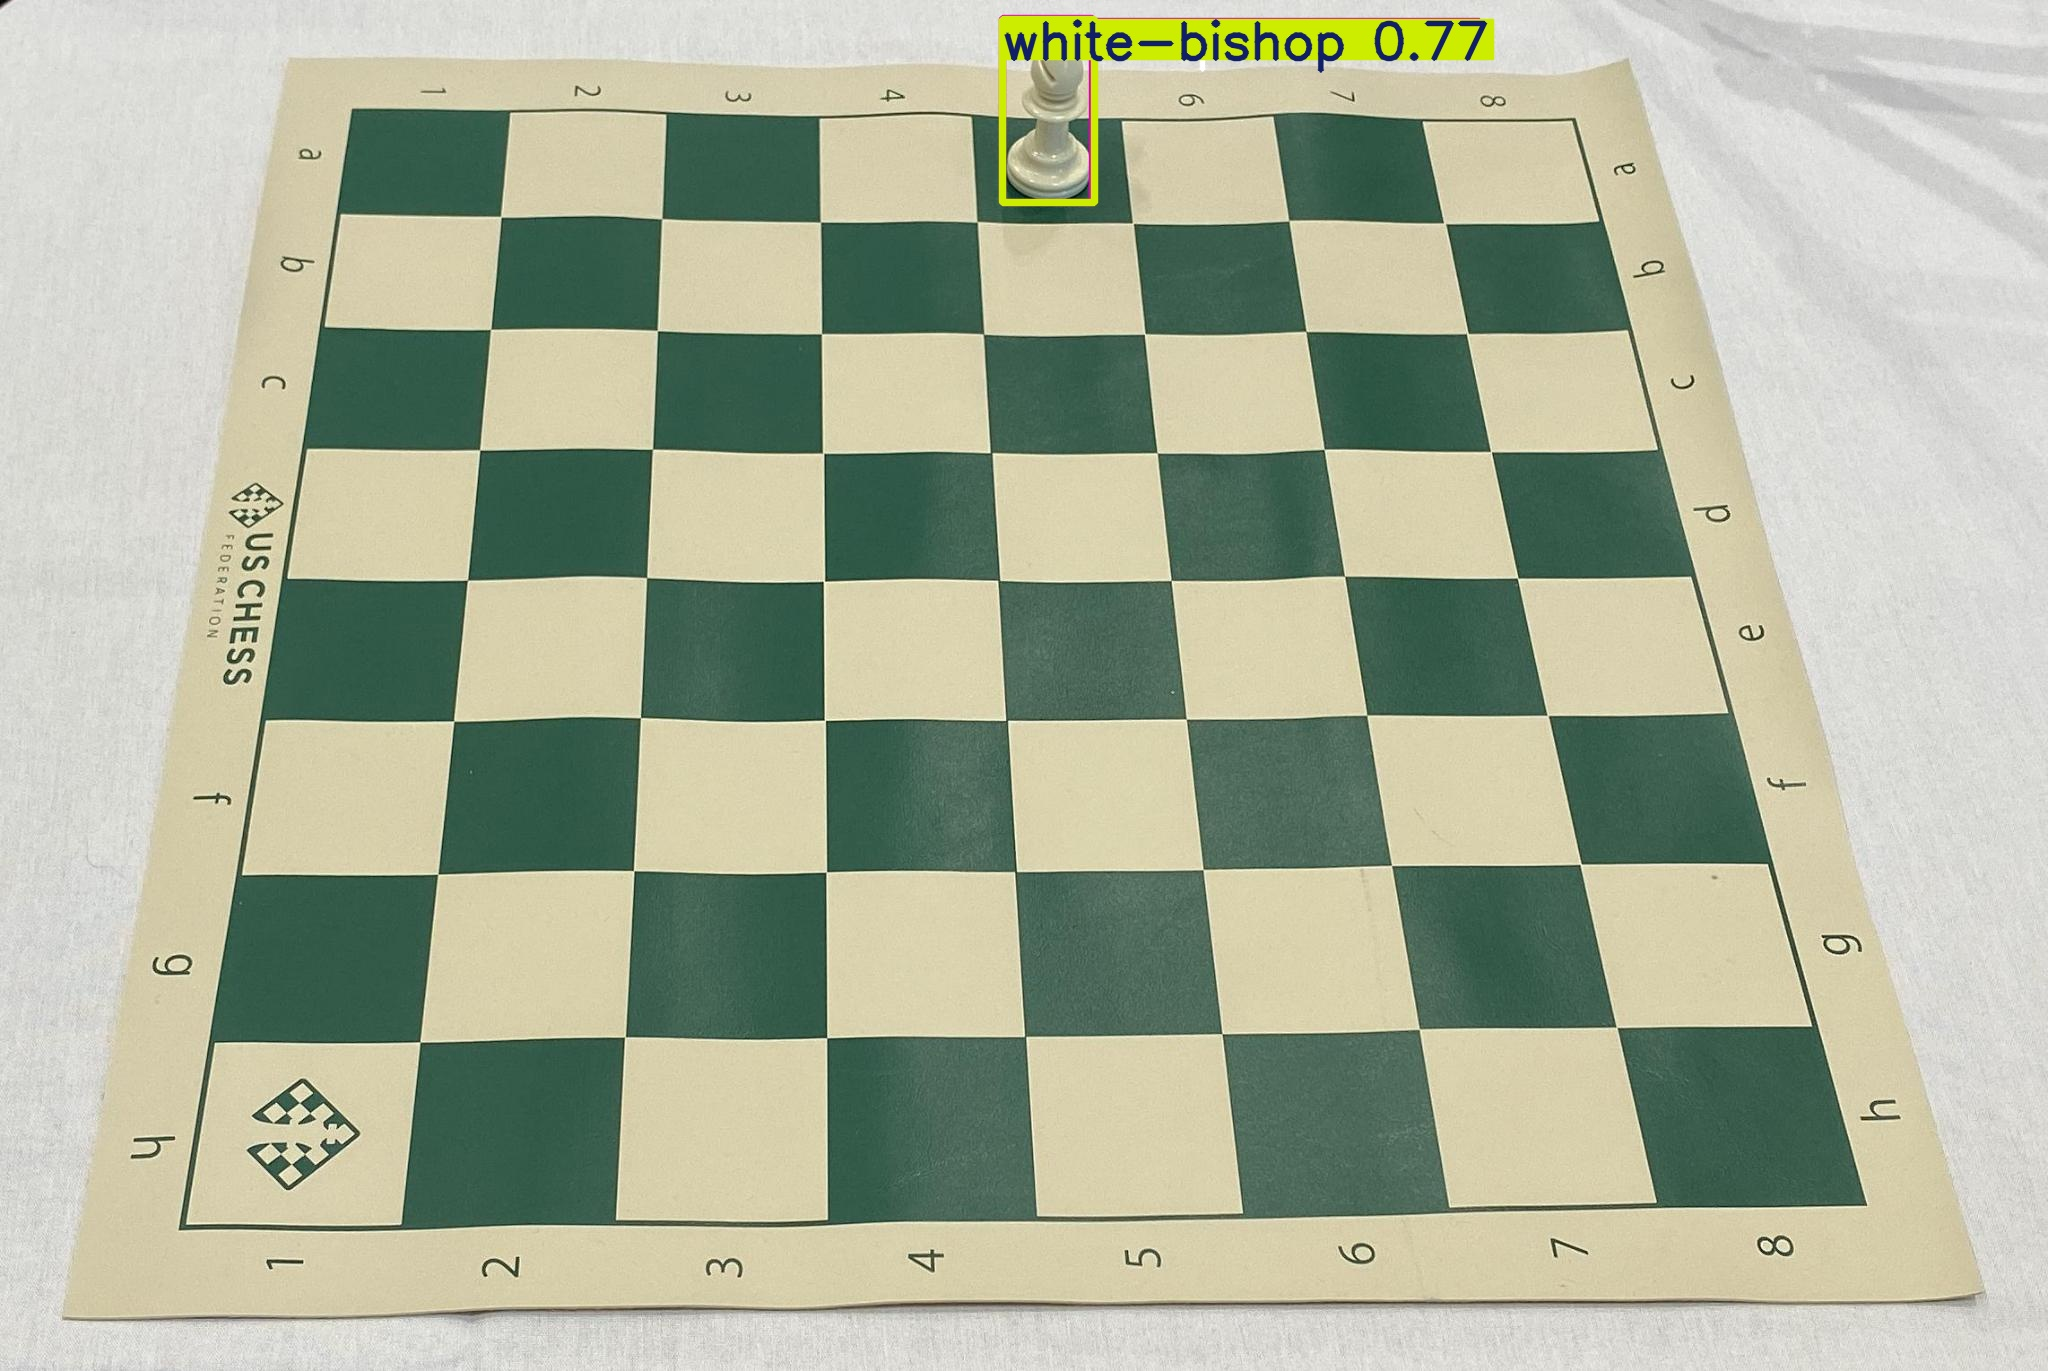

In [43]:
from ultralytics import YOLO

# Load the trained weights
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Perform inference on the test dataset
results = model.predict(source='/content/dataset/test/images', save=True)

# Display a prediction
from IPython.display import Image
Image(filename='/content/runs/detect/predict/0b47311f426ff926578c9d738d683e76_jpg.rf.0b55f43ac16aa65c889558d8ea757072.jpg')

In [44]:
# Evaluate the model on the validation set
metrics = model.val()
print(metrics)


Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)


val: Scanning /content/dataset/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:03<00:00,  1.11it/s]


                   all         58        386      0.982      0.983      0.983      0.806
          black-bishop         13         22      0.943      0.955      0.963      0.715
            black-king         29         29          1      0.958      0.995      0.842
          black-knight         26         30      0.992          1      0.995      0.853
            black-pawn         25         77      0.996          1      0.995      0.807
           black-queen         11         11          1      0.998      0.995      0.849
            black-rook         24         28          1      0.958      0.995      0.806
          white-bishop         17         22      0.929          1      0.956      0.745
            white-king         29         29          1      0.992      0.995      0.844
          white-knight         17         19      0.938          1      0.945      0.765
            white-pawn         26         77          1      0.994      0.995      0.801
           white-quee

In [45]:
from ultralytics import YOLO

# Load YOLOv8 weights
yolov8_model = YOLO('/content/drive/MyDrive/best.pt')


In [46]:
yolov8_metrics = yolov8_model.val()
print(yolov8_metrics)

Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 11,130,615 parameters, 0 gradients, 28.5 GFLOPs


val: Scanning /content/dataset/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:03<00:00,  1.30it/s]


                   all         58        386      0.984      0.992      0.985      0.815
          black-bishop         13         22          1      0.943      0.965      0.722
            black-king         29         29      0.993          1      0.995       0.88
          black-knight         26         30      0.998          1      0.995       0.87
            black-pawn         25         77      0.997          1      0.995      0.805
           black-queen         11         11      0.978          1      0.995      0.852
            black-rook         24         28      0.991          1      0.995       0.77
          white-bishop         17         22      0.946          1      0.954      0.745
            white-king         29         29      0.994          1      0.995       0.84
          white-knight         17         19      0.941          1      0.967      0.807
            white-pawn         26         77      0.997          1      0.995      0.804
           white-quee

In [47]:
yolov8_results = yolov8_model.predict(source='/content/dataset/test/images', save=True)


image 1/29 /content/dataset/test/images/0b47311f426ff926578c9d738d683e76_jpg.rf.0b55f43ac16aa65c889558d8ea757072.jpg: 448x640 1 white-bishop, 36.2ms
image 2/29 /content/dataset/test/images/1c0060ef868bdc326ce5e6389cb6732f_jpg.rf.9ce88078ea356949f4ab7ad9cfdfc62d.jpg: 448x640 1 white-rook, 13.0ms
image 3/29 /content/dataset/test/images/2f6fb003bb89cd401322a535acb42f65_jpg.rf.91ad9df05bd1f86bab67c8368ae5e4ad.jpg: 448x640 2 black-bishops, 1 black-king, 2 black-knights, 8 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 8 white-pawns, 1 white-queen, 2 white-rooks, 13.0ms
image 4/29 /content/dataset/test/images/410993714e325a1de3e394ffe860df3a_jpg.rf.519bf0fdbd5e38cd44cae1cfebc98536.jpg: 448x640 2 black-bishops, 1 black-king, 2 black-knights, 6 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 6 white-pawns, 1 white-queen, 1 white-rook, 13.1ms
image 5/29 /content/dataset/test/images/4e3117459d759798537eb52cf5

In [49]:
yolov9_model = YOLO('/content/drive/MyDrive/best_weights.pt')
yolov9_model.train(
    data='/content/dataset/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=/content/drive/MyDrive/best_weights.pt, data=/content/dataset/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, 

train: Scanning /content/dataset/train/labels.cache... 202 images, 0 backgrounds, 0 corrupt: 100%|██████████| 202/202 [00:00<?, ?it/s]

train: WARNING ⚠️ /content/dataset/train/images/26d663ab5ffbec49f9dc8e592982cfd4_jpg.rf.b18d279ba4125fd80a1d12ac0e771a97.jpg: 1 duplicate labels removed
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/dataset/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]


Plotting labels to runs/detect/train3/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000588, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train3
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         58        386      0.978      0.978      0.985      0.807



10 epochs completed in 0.023 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 6.2MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.36it/s]


                   all         58        386      0.978      0.978      0.985      0.808
          black-bishop         13         22      0.982      0.955      0.965      0.711
            black-king         29         29          1      0.954      0.995      0.818
          black-knight         26         30      0.989          1      0.995      0.841
            black-pawn         25         77      0.996          1      0.995      0.813
           black-queen         11         11       0.92          1      0.995       0.84
            black-rook         24         28          1      0.971      0.995      0.795
          white-bishop         17         22      0.941          1      0.964      0.751
            white-king         29         29       0.98      0.966      0.994      0.849
          white-knight         17         19      0.938          1      0.959      0.806
            white-pawn         26         77          1      0.994      0.995      0.812
           white-quee

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f996a09cfa0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [50]:
yolov9_metrics = yolov9_model.val()
print(yolov9_metrics)


Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/dataset/valid/labels.cache... 58 images, 0 backgrounds, 0 corrupt: 100%|██████████| 58/58 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:03<00:00,  1.13it/s]


                   all         58        386      0.978      0.978      0.985      0.806
          black-bishop         13         22      0.982      0.955      0.965      0.713
            black-king         29         29          1      0.954      0.995      0.822
          black-knight         26         30      0.989          1      0.995      0.848
            black-pawn         25         77      0.996          1      0.995      0.802
           black-queen         11         11      0.917          1      0.995      0.831
            black-rook         24         28          1       0.97      0.995      0.797
          white-bishop         17         22      0.941          1      0.964      0.744
            white-king         29         29       0.98      0.966      0.994      0.849
          white-knight         17         19      0.938          1      0.959        0.8
            white-pawn         26         77          1      0.994      0.995      0.812
           white-quee

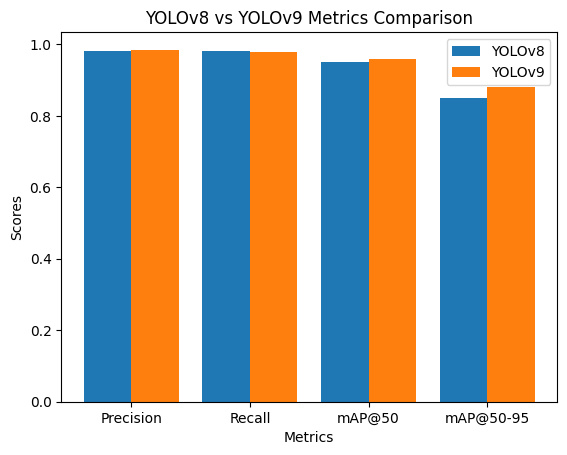

In [51]:
import matplotlib.pyplot as plt

# Define metrics and their scores
metrics = ['Precision', 'Recall', 'mAP@50', 'mAP@50-95']
yolov8_scores = [0.981, 0.982, 0.95, 0.85]
yolov9_scores = [0.985, 0.980, 0.96, 0.88]

# Create bar chart
x = range(len(metrics))
plt.bar(x, yolov8_scores, width=0.4, label='YOLOv8', align='center')
plt.bar([p + 0.4 for p in x], yolov9_scores, width=0.4, label='YOLOv9', align='center')

# Add labels and title
plt.xticks([p + 0.2 for p in x], metrics)
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.legend()
plt.title('YOLOv8 vs YOLOv9 Metrics Comparison')
plt.show()
